In [5]:
import numpy as np
import matplotlib.pyplot as plt
import overlappingGenes as opt
import os
import time

base_dir = os.getcwd()
dcaparams1 = os.path.join(base_dir, "PF00004", "PF00004_params.dat")
dcaparams2 = os.path.join(base_dir, "PF00041", "PF00041_params.dat")

print(f"Looking for data at: {dcaparams1}")
assert os.path.exists(dcaparams1), "Error: Data file not found."

# Load data
print("Loading parameters...")
Js_1, hs_1 = opt.extract_params(dcaparams1)
Js_2, hs_2 = opt.extract_params(dcaparams2)
DCA_params_1 = [Js_1, hs_1]
DCA_params_2 = [Js_2, hs_2]
lenprot1 = len(hs_1)/21
lenprot2 = len(hs_2)/21
overlapLen = 62

# Seed for initial sequence
print("Generating initial sequence...")
np.random.seed(42)
initialCondition = opt.initial_seq_no_stops(lenprot1, lenprot2, overlapLen, quiet=True)

iterations = 100

print(f"Running Original (Slow Numba) Algorithm ({iterations} iterations)...")
start_time = time.time()
opt.set_seed(123)
seq_orig, accepted_orig, E1_hist_orig, E2_hist_orig, finalE_orig = opt.overlapped_sequence_generator_slow(
    DCA_params_1, DCA_params_2, initialCondition, numberofiterations=iterations, T1=0.4, T2=0.5, quiet=True
)
print(f"Original finished in {time.time() - start_time:.2f}s")

print(f"Running Optimized (Fast Numba) Algorithm ({iterations} iterations)...")
start_time = time.time()
opt.set_seed(123)
seq_opt, accepted_opt, E1_hist_opt, E2_hist_opt, finalE_opt, _, _ = opt.overlapped_sequence_generator_int(
    DCA_params_1, DCA_params_2, initialCondition, numberofiterations=iterations, T1=0.4, T2=0.5, quiet=True
)
print(f"Optimized finished in {time.time() - start_time:.2f}s")

# Verification
match = (seq_orig == seq_opt)
print(f"Sequences Identical: {match}")

if not match:
    print("WARNING: Sequences differ!")
    for i, (a, b) in enumerate(zip(seq_orig, seq_opt)):
        if a != b:
            print(f"First difference at index {i}: {a} vs {b}")
            break
else:
    print("SUCCESS: Results are exactly the same.")

Looking for data at: c:\Users\orson\OneDrive\Documents\OverlappingGenes\Project\PF00004\PF00004_params.dat
Loading parameters...
Generating initial sequence...
Running Original (Slow Numba) Algorithm (100 iterations)...
Original finished in 0.00s
Running Optimized (Fast Numba) Algorithm (100 iterations)...
Optimized finished in 0.00s
Sequences Identical: True
SUCCESS: Results are exactly the same.


Plot saved to genome_comparison.png


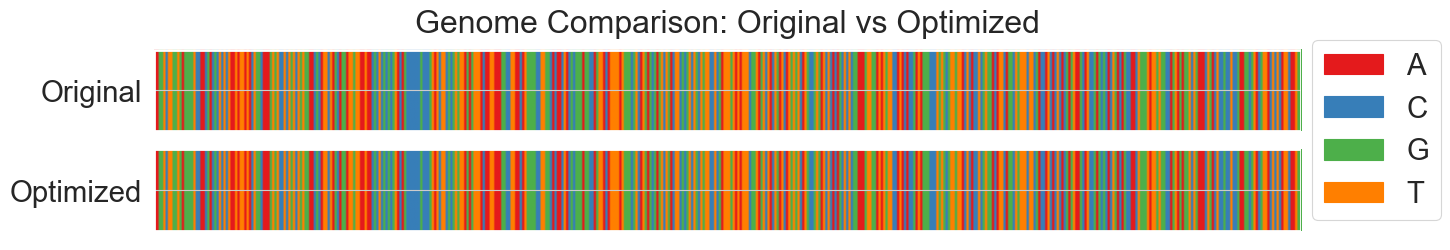

In [11]:
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=2.4)
# Map bases to colors
color_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
# Colors: A=Red, C=Blue, G=Green, T=Yellow/Orange
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

arr1 = np.array([color_map[b] for b in seq_orig])
arr2 = np.array([color_map[b] for b in seq_opt])

fig, ax = plt.subplots(figsize=(15, 3))

# Create colormap
cmap = plt.cm.colors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

# Plot seq_orig (Original) - Top bar
ax.imshow(arr1.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm, extent=[0, len(seq_orig), 1.1, 2.0])

# Plot seq_opt (Optimized) - Bottom bar
ax.imshow(arr2.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm, extent=[0, len(seq_opt), 0.0, 0.9])

# Borders
rect1 = Rectangle((0, 1.1), len(seq_orig), 0.9, linewidth=2, edgecolor='white', facecolor='none')
ax.add_patch(rect1)
rect2 = Rectangle((0, 0.0), len(seq_opt), 0.9, linewidth=2, edgecolor='white', facecolor='none')
ax.add_patch(rect2)

ax.set_ylim(-0.1, 2.1)
ax.set_yticks([0.45, 1.55])
ax.set_yticklabels(['Optimized', 'Original'])

ax.set_xticks([])
ax.set_title('Genome Comparison: Original vs Optimized')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Legend
patches = [mpatches.Patch(color=colors[i], label=base) for base, i in color_map.items()]
plt.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig('genome_comparison.png', dpi=300)
print("Plot saved to genome_comparison.png")
plt.show()